In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv('../data/features_JNJ.csv', index_col = 0)
df.head()

,Adj Close,Close,High,Low,Open,Volume,ret_1d,ret_5d,red_20d,vol_5d,vol_20d,ma_10,ma_20,price_to_ma20,vol_chg,vol_z20,y_reg,y_class
20,78.394852,103.410004,104.260002,103.000000,103.300003,10616300,-0.009198,0.022040,0.029160,0.011537,0.015803,76.012145,75.338198,0.040572,0.082887,-0.097366,0.007059,1
21,78.948273,104.139999,104.379997,102.010002,103.650002,10168600,0.007059,0.019382,0.032111,0.011295,0.015841,76.648190,75.461009,0.046213,-0.042171,-0.296495,-0.002305,0
22,78.766312,103.900002,104.089996,102.730003,103.610001,10389000,-0.002305,0.015938,0.034963,0.011603,0.015791,77.251639,75.594054,0.041964,0.021675,-0.277514,-0.032339,0
23,76.219093,100.540001,102.769997,99.779999,102.660004,15522200,-0.032339,-0.037342,0.013303,0.015046,0.017324,77.538956,75.644087,0.007601,0.494100,1.209093,0.014522,1
24,77.325943,102.000000,103.510002,100.220001,100.309998,14323800,0.014522,-0.022708,0.039120,0.018009,0.017361,77.963491,75.789642,0.020271,-0.077206,0.766467,-0.000294,0


In [18]:
inputs = df.drop(['y_reg', 'y_class'], axis = 'columns')
target = df['y_class']

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(inputs, target, test_size = 0.5, shuffle = False, random_state = None)

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [35]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits = 5)

In [36]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

In [37]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train) 
y_pred_baseline = baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_baseline)

In [38]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [39]:
model_params = {
    'logistic_regression': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(random_state=42, max_iter=1000))
        ]),
        'params': {
            'clf__C': [0.01, 0.1, 1, 10, 100],  
            'clf__penalty': ['l2']
        }
    },
    'svm': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(random_state=42, probability=True))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__kernel': ['linear', 'rbf'],
            'clf__gamma': ['scale', 'auto']
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(random_state=42),  
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 20, None]
        }
    }
}

In [40]:
from sklearn.model_selection import RandomizedSearchCV

scores = []
for model_name, mp in model_params.items():
    clf = RandomizedSearchCV(mp['model'], mp['params'], n_iter = 10, cv = tscv, return_train_score = False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': model_name, 
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [41]:
scores


[{'model': 'logistic_regression',
  'best_score': np.float64(0.5371980676328503),
  'best_params': {'clf__penalty': 'l2', 'clf__C': 100}},
 {'model': 'svm',
  'best_score': np.float64(0.5314009661835748),
  'best_params': {'clf__kernel': 'linear',
   'clf__gamma': 'auto',
   'clf__C': 10}},
 {'model': 'random_forest',
  'best_score': np.float64(0.5120772946859904),
  'best_params': {'n_estimators': 100, 'max_depth': None}}]

In [42]:
model = LogisticRegression(penalty = 'l2', C = 10)

In [43]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
model.score(X_test, y_test)

0.5196471531676022

Text(95.72222222222221, 0.5, 'Truth')

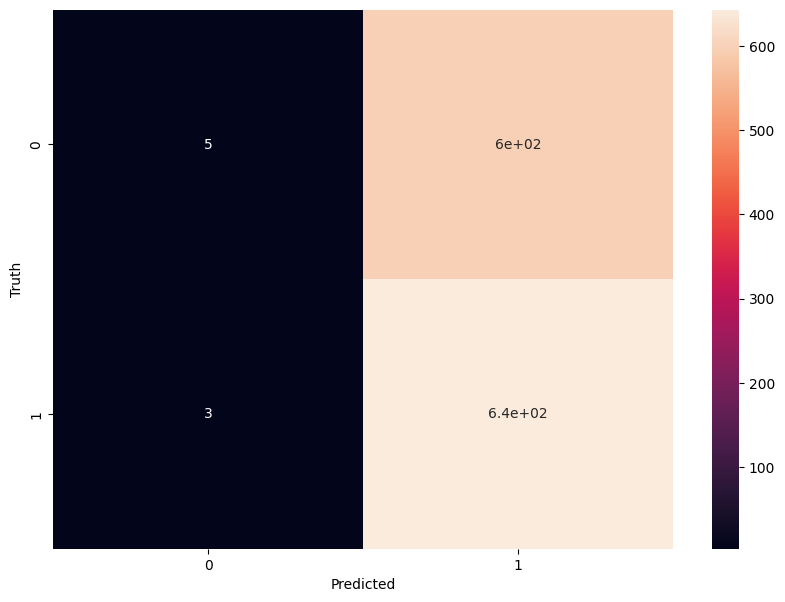

In [45]:
y_predicted = model.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
import seaborn as sn
plt.figure(figsize = (10, 7))
sn.heatmap(cm, annot = True)
plt.xlabel('Predicted')
plt.ylabel('Truth')